In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'c:\\Users\\luisa\\Documents\\LX1_GitHub_Repos\\ai_cheme_examples'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

from scipy import stats
from scipy import interpolate
from scipy.interpolate import CubicSpline

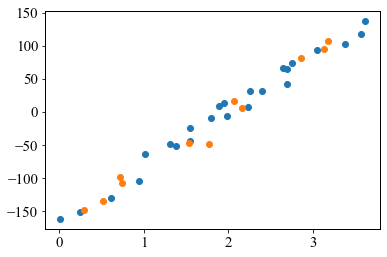

In [15]:
X, y = make_regression(n_samples=35, n_features=1, noise=15, random_state=21)

X  = X + 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=13)

plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test)


In [16]:
train_set = np.array([X_train[:, 0], y_train]).reshape(2, -1).transpose()

train_set = train_set[train_set[:, 0].argsort()]

X_train_sorted = train_set[:, 0]
y_train_sorted = train_set[:, 1]

train_set

array([[ 1.58183857e-02, -1.61602723e+02],
       [ 2.52666205e-01, -1.51292010e+02],
       [ 6.16043131e-01, -1.30433468e+02],
       [ 9.38143382e-01, -1.03787153e+02],
       [ 1.01063161e+00, -6.35035383e+01],
       [ 1.31077173e+00, -4.78656698e+01],
       [ 1.38679971e+00, -5.12681579e+01],
       [ 1.54227677e+00, -4.45574477e+01],
       [ 1.55188440e+00, -2.46567908e+01],
       [ 1.79413562e+00, -8.58899071e+00],
       [ 1.88880395e+00,  9.44788097e+00],
       [ 1.94803575e+00,  1.39990838e+01],
       [ 1.98737405e+00, -5.43246725e+00],
       [ 2.23180296e+00,  7.96780082e+00],
       [ 2.25722913e+00,  3.21572890e+01],
       [ 2.40272379e+00,  3.13282109e+01],
       [ 2.64415927e+00,  6.56952207e+01],
       [ 2.69192371e+00,  6.54486958e+01],
       [ 2.69717660e+00,  4.25649275e+01],
       [ 2.74538768e+00,  7.36748473e+01],
       [ 3.04179680e+00,  9.29986973e+01],
       [ 3.37368850e+00,  1.02378298e+02],
       [ 3.56788218e+00,  1.18098281e+02],
       [ 3.

In [27]:
f0 = interpolate.interp1d(X_train_sorted, y_train_sorted)
f1 = CubicSpline(X_train_sorted, y_train_sorted)

In [28]:
y_predicted0 = f0(X_test).reshape(-1, )
y_predicted1 = f1(X_test).reshape(-1, )

y_predicted0train = f0(X_train).reshape(-1, )
y_predicted1train = f1(X_train).reshape(-1, )

y_predicted = []

for y in [y_predicted0train, y_predicted1train]:
    predicted_set = np.array([X_train.reshape(-1, ), y]).reshape(2, -1).transpose()
    predicted_set = predicted_set[predicted_set[:, 0].argsort()]
    X_train_sorted = predicted_set[:, 0]
    y = predicted_set[:, 1]

    y_predicted.append(y)

for y in [y_predicted0, y_predicted1]:
    predicted_set = np.array([X_test.reshape(-1, ), y]).reshape(2, -1).transpose()
    predicted_set = predicted_set[predicted_set[:, 0].argsort()]
    X_test_sorted = predicted_set[:, 0]
    y = predicted_set[:, 1]

    y_predicted.append(y)



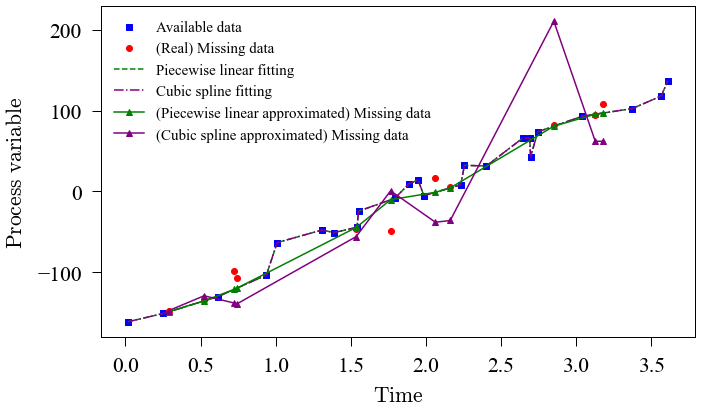

In [32]:
fig = plt.figure(figsize=(10, 6))
axs0 = fig.add_subplot(1, 1, 1)

axs0.scatter(X_train, y_train, color = 'b', label = 'Available data', marker = 's')
axs0.scatter(X_test, y_test, color = 'r', label = '(Real) Missing data')

axs0.plot(X_train_sorted, y_predicted[0], color = 'g', ls = '--', label = 'Piecewise linear fitting')
axs0.plot(X_train_sorted, y_predicted[1], color = 'purple', ls = '-.', label = 'Cubic spline fitting')


axs0.plot(X_test_sorted, y_predicted[2], color = 'g', ls = '-', marker = '^', label = '(Piecewise linear approximated) Missing data')
axs0.plot(X_test_sorted, y_predicted[3], color = 'purple', ls = '-', marker = '^', label = '(Cubic spline approximated) Missing data')

axs0.set_xlabel(r'$ \rm Time$', labelpad = 10, fontsize='x-large')
axs0.set_ylabel(r'$ \rm Process\ variable$', labelpad = 10, fontsize='x-large')

axs0.tick_params(direction='out',
                    pad=10,
                    length=9,
                    width=1,
                    labelsize='x-large')

axs0.tick_params(which='minor',
                    direction='out',
                    pad=10,
                    length=5,
                    width=1,
                    labelsize='x-large')

for ax in ['top', 'bottom', 'left', 'right']:
    axs0.spines[ax].set_linewidth(1)


plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=15
plt.rcParams['axes.linewidth'] = 1 

plt.legend(frameon = False)
plt.tight_layout()

plt.savefig('figures/example-2-2.png', dpi = 300)

plt.show()